# Train and Tune XGBoost Model Non-Deterministic (Paralleled)

In [1]:
from pathlib import Path

import optuna.visualization as vis
import pandas as pd

from config.config import Config
from src.data import time_series_split
from src.models.factory import Experiment
from src.models.xgboost import XGBoost
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_test_overlay, plot_val_overlay, plot_val_test_overlay
from src.runners import run_experiments
from src.utils import set_seed

In [2]:
cfg = Config(Path("../config/config.yaml"))
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
rng = set_seed(SEED)

2025-08-29 19:15:26,521 - INFO - src.utils - Global random seed set to 42


In [3]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")

In [4]:
MODEL_NAME = "xgboost"

In [5]:
# GPU Variant
experiments = [
    Experiment(
        name=MODEL_NAME,
        build=lambda horizon, seed: XGBoost(
            horizon=horizon,
            random_state=seed,
            device="cuda",
            tree_method="hist",
            n_jobs=1,
            outer_n_jobs=1,
        ),
        include_sentiment=True,
    )
]

In [6]:
# # CPU Variant
# experiments = [
#     Experiment(
#         name=MODEL_NAME,
#         build=lambda horizon, seed: XGBoost(
#             horizon=horizon,
#             random_state=seed,
#             device="cpu",
#             n_jobs=-1,
#             outer_n_jobs=1
#         ),
#         include_sentiment=True,
#     )
# ]

In [7]:
results = run_experiments(df_full, Path(cfg.data.processed_dir), experiments, HORIZON, SEED, n_trials=300, n_splits=3)

2025-08-29 19:15:26,633 - INFO - ModelTrainer - Initialized ModelTrainer for model: xgboost
D:\IntelliJ\ml-stock-sent\.venv\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
D:\IntelliJ\ml-stock-sent\.venv\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-08-29 19:15:26,634] A new study created in memory with name: no-name-fd917bc9-a7eb-46bd-a0ed-51c53a21a8e5
2025-08-29 19:15:26,635 - INFO - ModelTrainer - Starting model tuning...
2025-08-29 19:15:26,637 - INFO - ModelTrainer - Starting model tuning...
2025-08-29 19:15:26,639 - INFO - ModelTrainer - Starting model tuning...
2025-08-29 19:15:26,641 - INFO - ModelTrainer - Starting model tuning...
2025-08-29 19:15:26,643 - INFO - ModelTrainer - Starting model tuning...
2025-08-

In [8]:
train, val, test, forecast = time_series_split(df_full, train_ratio=0.8, val_ratio=0.1, horizon=HORIZON)

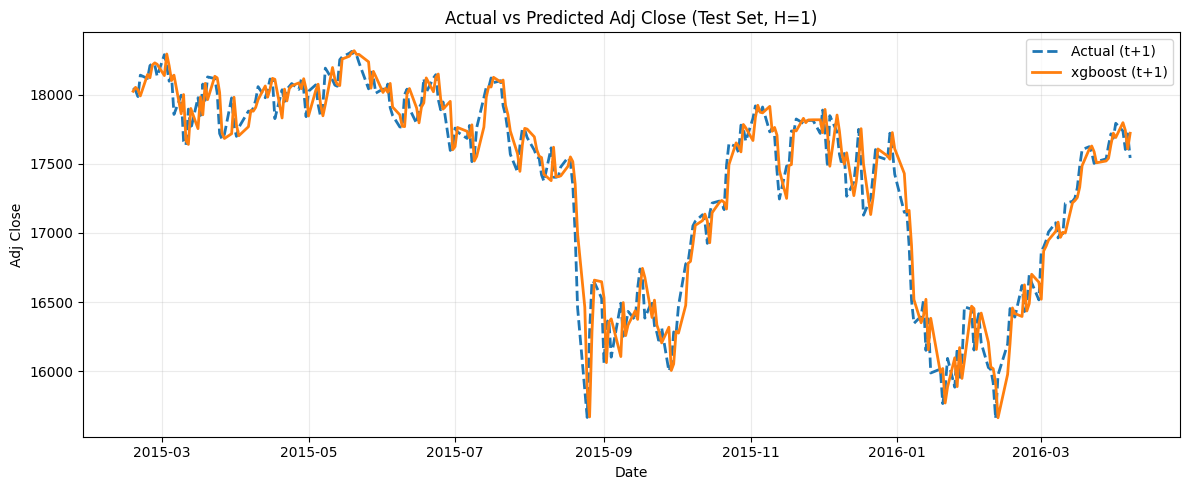

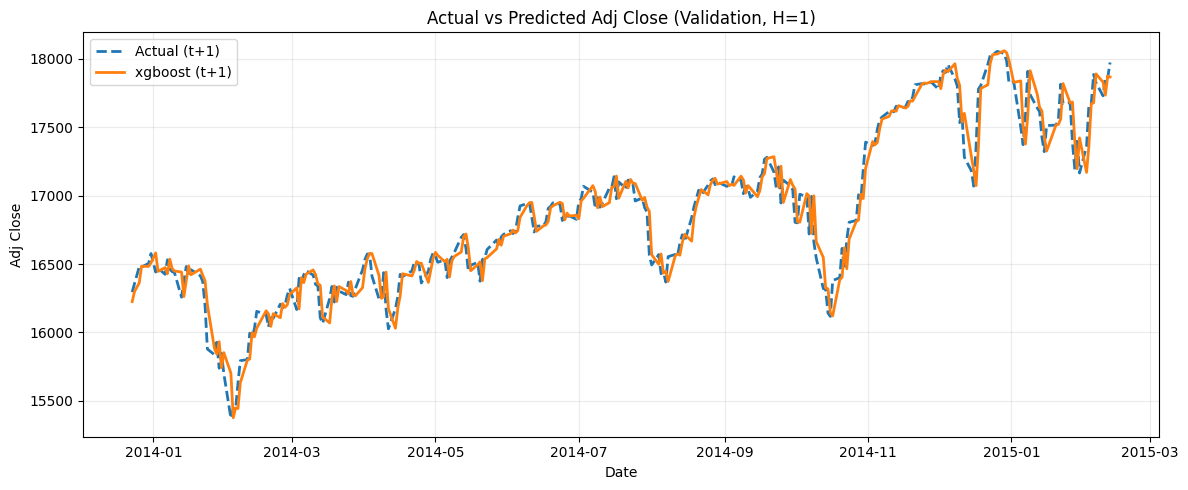

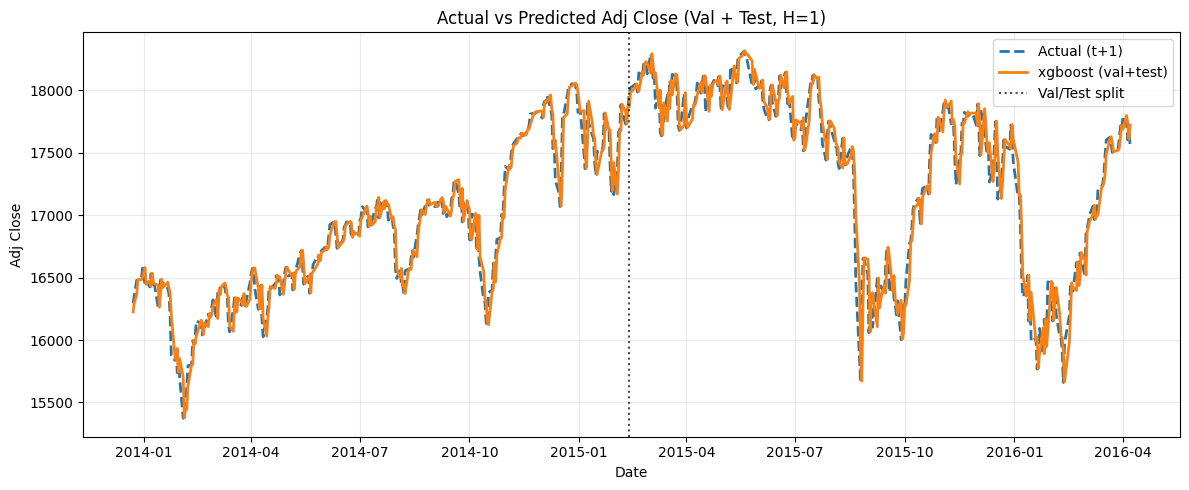

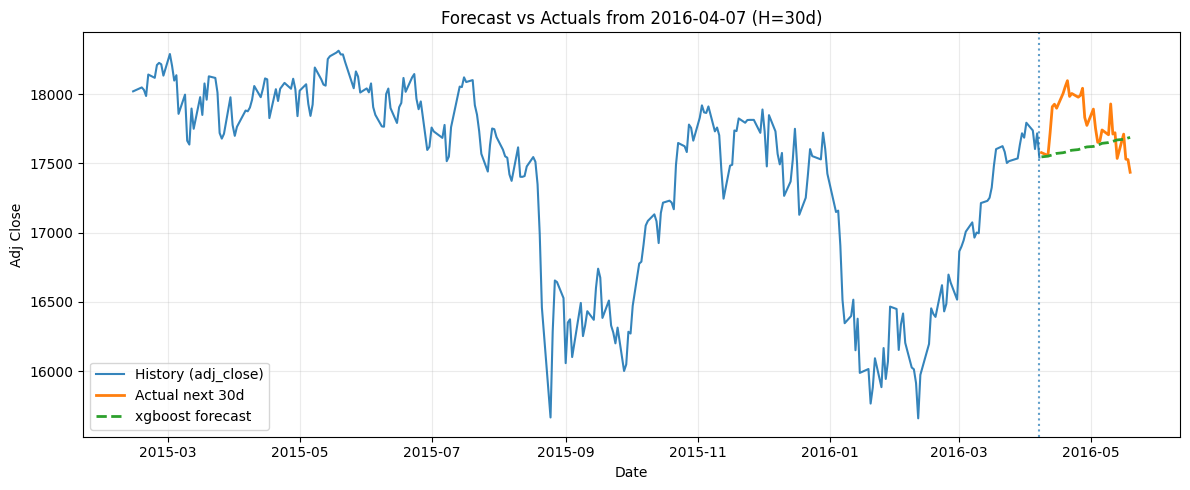

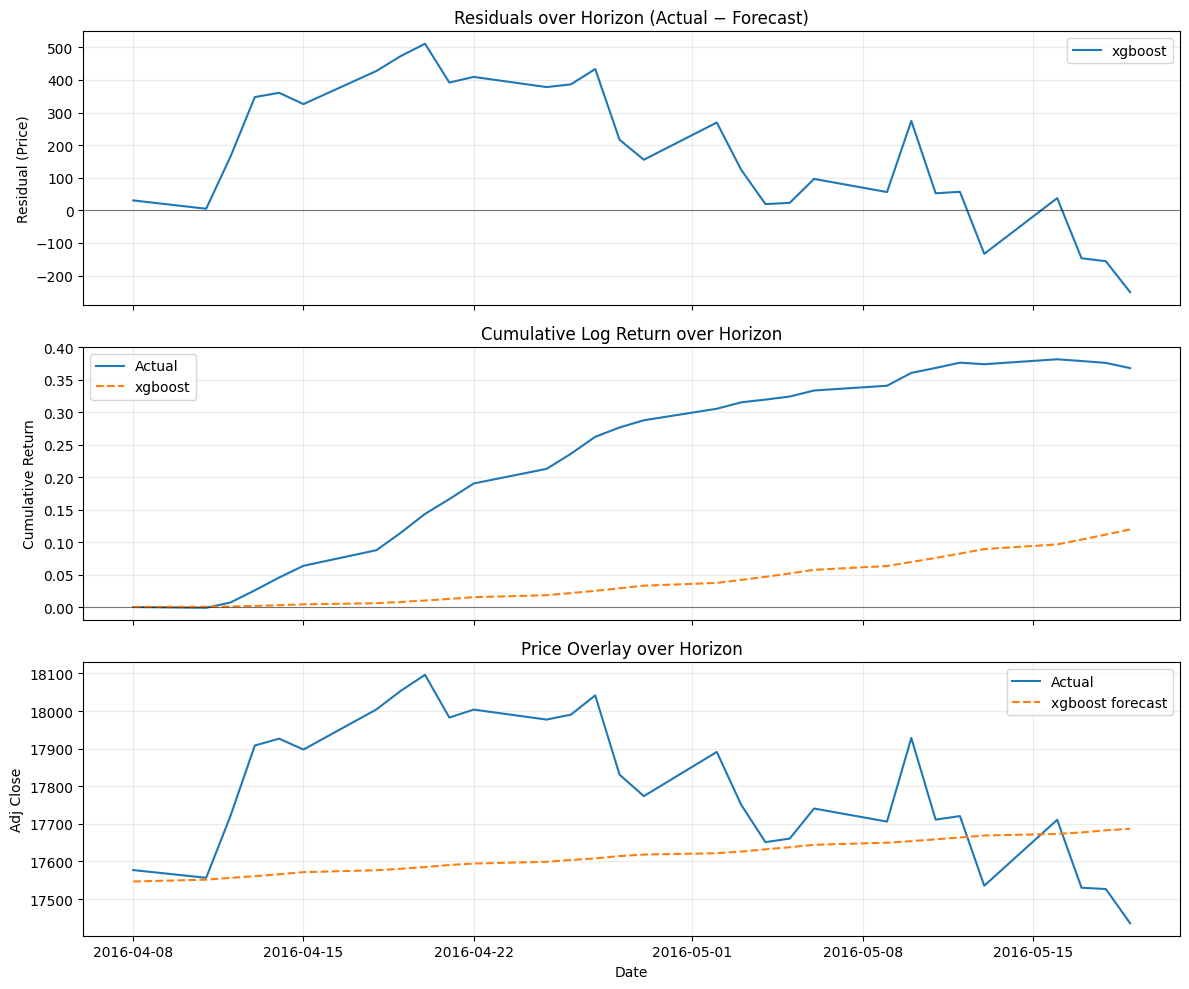

In [9]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close.png")
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val.png")
plot_val_test_overlay(val, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val_test.png")
plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast.png")
plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast_diagnostics.png")

In [10]:
pd.DataFrame(results[0]["best_params"], index=[0])

,n_estimators,learning_rate,max_depth,subsample,colsample_bytree,min_child_weight,reg_alpha,reg_lambda,gamma,early_stopping_rounds,max_bin,grow_policy,objective,eval_metric,tree_method,max_leaves,random_state
0,800,0.038132,8,0.641283,0.732337,9.348281,0.148898,0.222992,1.16167,100,256,depthwise,reg:squarederror,mae,hist,0,42


In [11]:
pd.DataFrame(results[0]["metrics"]["test"], index=[0])

,mae,mse,rmse,smape,r2
0,0.007408,0.000098,0.009913,1.839164,-0.001019


In [12]:
study = results[0]["study"]

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()
vis.plot_slice(study).show()
vis.plot_parallel_coordinate(study).show()
vis.plot_contour(study).show()
vis.plot_edf(study).show()

[W 2025-08-29 19:32:46,950] Param objective unique value length is less than 2.
[W 2025-08-29 19:32:46,950] Param objective unique value length is less than 2.
[W 2025-08-29 19:32:46,951] Param objective unique value length is less than 2.
[W 2025-08-29 19:32:46,952] Param objective unique value length is less than 2.
[W 2025-08-29 19:32:46,953] Param objective unique value length is less than 2.
[W 2025-08-29 19:32:46,954] Param objective unique value length is less than 2.
[W 2025-08-29 19:32:46,955] Param objective unique value length is less than 2.
[W 2025-08-29 19:32:46,956] Param objective unique value length is less than 2.
[W 2025-08-29 19:32:46,957] Param objective unique value length is less than 2.
[W 2025-08-29 19:32:46,957] Param objective unique value length is less than 2.
[W 2025-08-29 19:32:46,958] Param objective unique value length is less than 2.
[W 2025-08-29 19:32:46,958] Param objective unique value length is less than 2.
[W 2025-08-29 19:32:46,958] Param object